# 04 — Manipulation Map

Tespit edilen manipülatif içerik kümelerinin **hangi dillerde ve platformlarda** yoğunlaştığını gösteren görsel rapor.

| Bölüm | Soru |
|---|---|
| 1 | Küme skor dağılımı — doğal sınırlar nerede? |
| 2 | Kategori profilleri — manipülatif vs organik feature farkı |
| 3 | Manipülasyon kümesi tanımı |
| 4 | Dil haritası — overrepresentation |
| 5 | Platform haritası — overrepresentation |
| 6 | Dil × Platform — Ana Manipülasyon Haritası |
| 7 | Radar — kategori sinyalleri |
| 8 | HTML export |

---

## Ön Bulgular — HDBSCAN Çıktısı

| Kategori | Kümeler | mean_organic_score | Post sayısı |
|---|---|---|---|
| **Manipülasyon** | 0 | 0.24 | ~92k |
| **Gri Bölge** | 1 – 5 | 0.53 – 0.68 | ~315k |
| **Organik** | 7 – 28 | 0.83 – 0.96 | ~2.9M |
| **Noise** | -1 | 0.84 | ~1.7M |

> **Doğal sınır:** Küme 4 (0.68) → Küme 7 (0.83) arasında 0.15 puanlık boşluk.
> Eşikler: Manipülasyon `< 0.50`, Gri Bölge `0.50 – 0.75`, Organik `≥ 0.75`.

## 0. Setup & Veri Yükleme

In [15]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

OUTPUTS_DIR = Path('../outputs')

CLUSTER_FEATURES = [
    'text_len', 'kw_count', 'kw_density', 'sentiment', 'sentiment_extreme',
    'is_duplicate', 'cross_author_dup_count', 'kw_fingerprint_shared', 'has_author',
]
LOAD_COLS = ['cluster', 'organic_score', 'language', 'domain'] + CLUSTER_FEATURES

post_clusters   = pd.read_parquet(OUTPUTS_DIR / 'post_clusters.parquet', columns=LOAD_COLS)
cluster_summary = pd.read_csv(OUTPUTS_DIR / 'cluster_summary.csv')

print(f'post_clusters  : {len(post_clusters):,} satir  |  {post_clusters.memory_usage(deep=True).sum()/1024**2:.0f} MB RAM')
print(f'cluster_summary: {len(cluster_summary)} kume')

# Eşikler ve kategori renkleri
MANIP_THRESHOLD    = 0.75
GREYZONE_THRESHOLD = 0.50

CAT_COLOR = {
    'Manipülasyon': '#c0392b',
    'Gri Bölge':    '#e67e22',
    'Organik':      '#27ae60',
    'Noise':        '#95a5a6',
}

def get_category(cid, score):
    if cid == -1:        return 'Noise'
    if score < GREYZONE_THRESHOLD: return 'Manipülasyon'
    if score < MANIP_THRESHOLD:    return 'Gri Bölge'
    return 'Organik'

post_clusters  : 5,004,813 satir  |  500 MB RAM
cluster_summary: 38 kume


## 1. Küme Skor Dağılımı

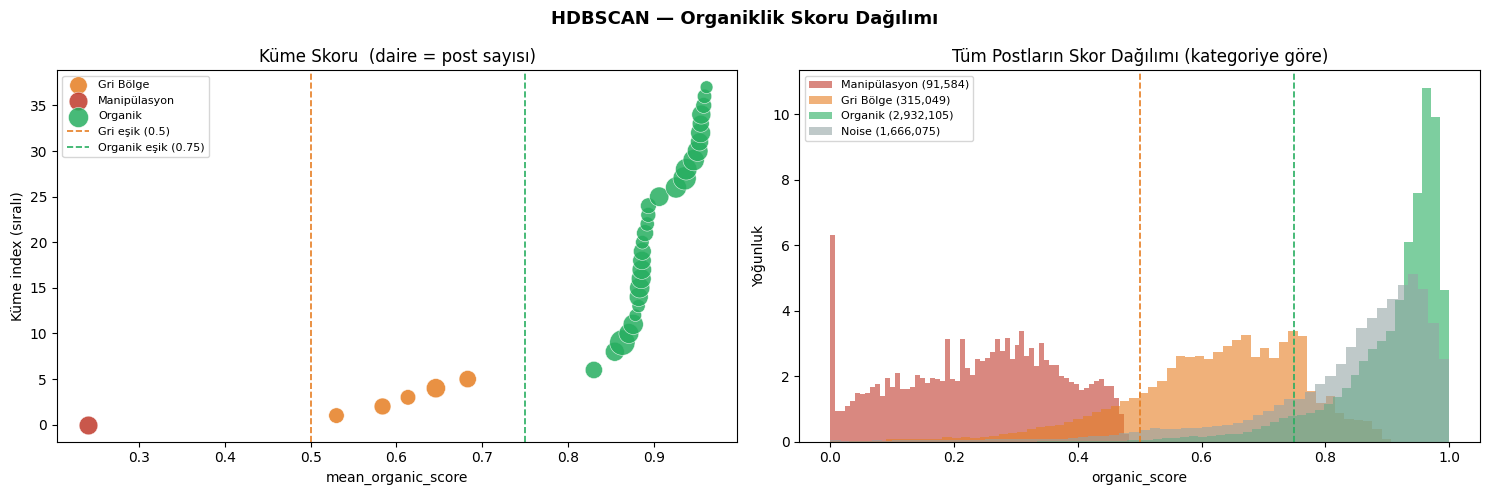

In [16]:
# Cluster başına mean skor + kategori
cs = cluster_summary.copy()
cs['category'] = cs.apply(lambda r: get_category(r['cluster'], r['mean_organic_score']), axis=1)
cs['color']    = cs['category'].map(CAT_COLOR)
cs = cs.sort_values('mean_organic_score')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sol: scatter — küme id vs skor, boyut = post sayısı
for cat, grp in cs[cs['cluster'] >= 0].groupby('category'):
    axes[0].scatter(
        grp['mean_organic_score'], grp.index,
        s=np.sqrt(grp['post_count']) * 0.6,
        color=CAT_COLOR[cat], label=cat, alpha=0.85, edgecolors='white', linewidths=0.4
    )
axes[0].axvline(GREYZONE_THRESHOLD, color='#e67e22', linestyle='--', lw=1.2, label=f'Gri eşik ({GREYZONE_THRESHOLD})')
axes[0].axvline(MANIP_THRESHOLD,    color='#27ae60', linestyle='--', lw=1.2, label=f'Organik eşik ({MANIP_THRESHOLD})')
axes[0].set_xlabel('mean_organic_score')
axes[0].set_ylabel('Küme index (sıralı)')
axes[0].set_title('Küme Skoru  (daire = post sayısı)')
axes[0].legend(fontsize=8)

# Sağ: tüm postların skor histogramı, kategoriye göre renkli
for cat in ['Manipülasyon', 'Gri Bölge', 'Organik', 'Noise']:
    cids = cs[cs['category'] == cat]['cluster'].tolist()
    scores = post_clusters[post_clusters['cluster'].isin(cids)]['organic_score']
    axes[1].hist(scores, bins=60, alpha=0.6, color=CAT_COLOR[cat], label=f'{cat} ({len(scores):,})', density=True)
axes[1].axvline(GREYZONE_THRESHOLD, color='#e67e22', linestyle='--', lw=1.2)
axes[1].axvline(MANIP_THRESHOLD,    color='#27ae60', linestyle='--', lw=1.2)
axes[1].set_xlabel('organic_score')
axes[1].set_ylabel('Yoğunluk')
axes[1].set_title('Tüm Postların Skor Dağılımı (kategoriye göre)')
axes[1].legend(fontsize=8)

plt.suptitle('HDBSCAN — Organiklik Skoru Dağılımı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'fig1_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Kategori Profilleri — Feature Farkı

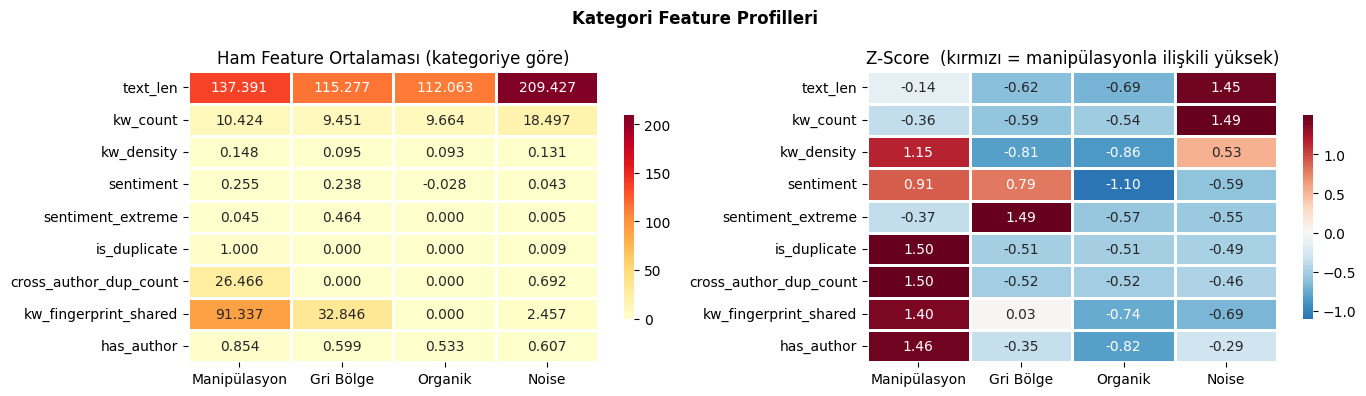

In [17]:
# Kategori ata
cs_cat = cs.set_index('cluster')['category'].to_dict()
post_clusters['category'] = post_clusters['cluster'].map(
    lambda c: cs_cat.get(c, 'Noise')
)

# 4 kategori ortalaması (37 küme yerine)
cat_means = post_clusters.groupby('category')[CLUSTER_FEATURES].mean()
cat_means = cat_means.reindex(['Manipülasyon', 'Gri Bölge', 'Organik', 'Noise'])

# Z-score normalize
cat_z = (cat_means - cat_means.mean()) / (cat_means.std() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(cat_means.T, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[0], linewidths=1, cbar_kws={'shrink': 0.7})
axes[0].set_title('Ham Feature Ortalaması (kategoriye göre)')
axes[0].set_xlabel('')

sns.heatmap(cat_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], linewidths=1, cbar_kws={'shrink': 0.7})
axes[1].set_title('Z-Score  (kırmızı = manipülasyonla ilişkili yüksek)')
axes[1].set_xlabel('')

plt.suptitle('Kategori Feature Profilleri', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'fig2_feature_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Manipülasyon Kümesi Tanımı

Toplam post              : 5,004,813
Manipülasyon ([0])  : 91,584  (1.8%)
Gri bölge [1, 2, 3, 5, 4]   : 315,049  (6.3%)
Organik                  : 2,932,105  (58.6%)
Noise                    : 1,666,075  (33.3%)


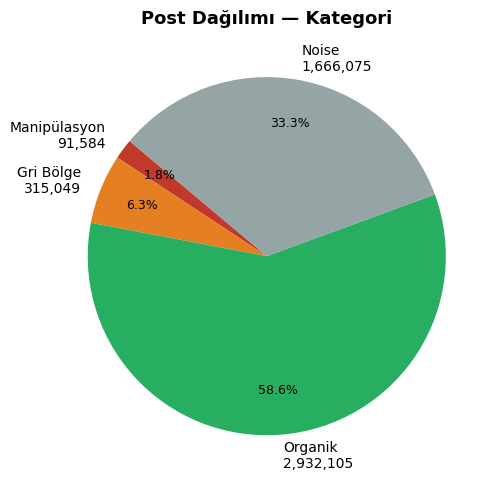

In [18]:
cs['is_manipulation'] = cs['category'].isin(['Manipülasyon', 'Gri Bölge'])

manip_ids    = cs[cs['category'] == 'Manipülasyon']['cluster'].tolist()
greyzone_ids = cs[cs['category'] == 'Gri Bölge']['cluster'].tolist()
organic_ids  = cs[cs['category'] == 'Organik']['cluster'].tolist()

post_clusters['is_manipulation'] = post_clusters['cluster'].isin(manip_ids + greyzone_ids)

n_total    = len(post_clusters)
n_noise    = (post_clusters['cluster'] == -1).sum()
n_manip    = post_clusters['cluster'].isin(manip_ids).sum()
n_grey     = post_clusters['cluster'].isin(greyzone_ids).sum()
n_organic  = post_clusters['cluster'].isin(organic_ids).sum()

print(f'Toplam post              : {n_total:,}')
print(f'Manipülasyon ({manip_ids})  : {n_manip:,}  ({n_manip/n_total*100:.1f}%)')
print(f'Gri bölge {greyzone_ids}   : {n_grey:,}  ({n_grey/n_total*100:.1f}%)')
print(f'Organik                  : {n_organic:,}  ({n_organic/n_total*100:.1f}%)')
print(f'Noise                    : {n_noise:,}  ({n_noise/n_total*100:.1f}%)')

# Pasta grafik — 4 kategori
fig, ax = plt.subplots(figsize=(7, 5))
sizes  = [n_manip, n_grey, n_organic, n_noise]
labels = [f'Manipülasyon\n{n_manip:,}', f'Gri Bölge\n{n_grey:,}',
          f'Organik\n{n_organic:,}', f'Noise\n{n_noise:,}']
colors = [CAT_COLOR[k] for k in ['Manipülasyon', 'Gri Bölge', 'Organik', 'Noise']]
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                   autopct='%1.1f%%', startangle=140,
                                   pctdistance=0.75, labeldistance=1.12)
for t in autotexts: t.set_fontsize(9)
ax.set_title('Post Dağılımı — Kategori', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'fig3_category_pie.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Dil Haritası — Overrepresentation

**Overrepresentation** = manipülatif post'lardaki dil oranı / tüm verisetindeki dil oranı

- `> 1` : Bu dil manipülasyonda normalden **fazla** temsil ediliyor
- `= 1` : Beklenen oranda
- `< 1` : Beklenen oranın altında

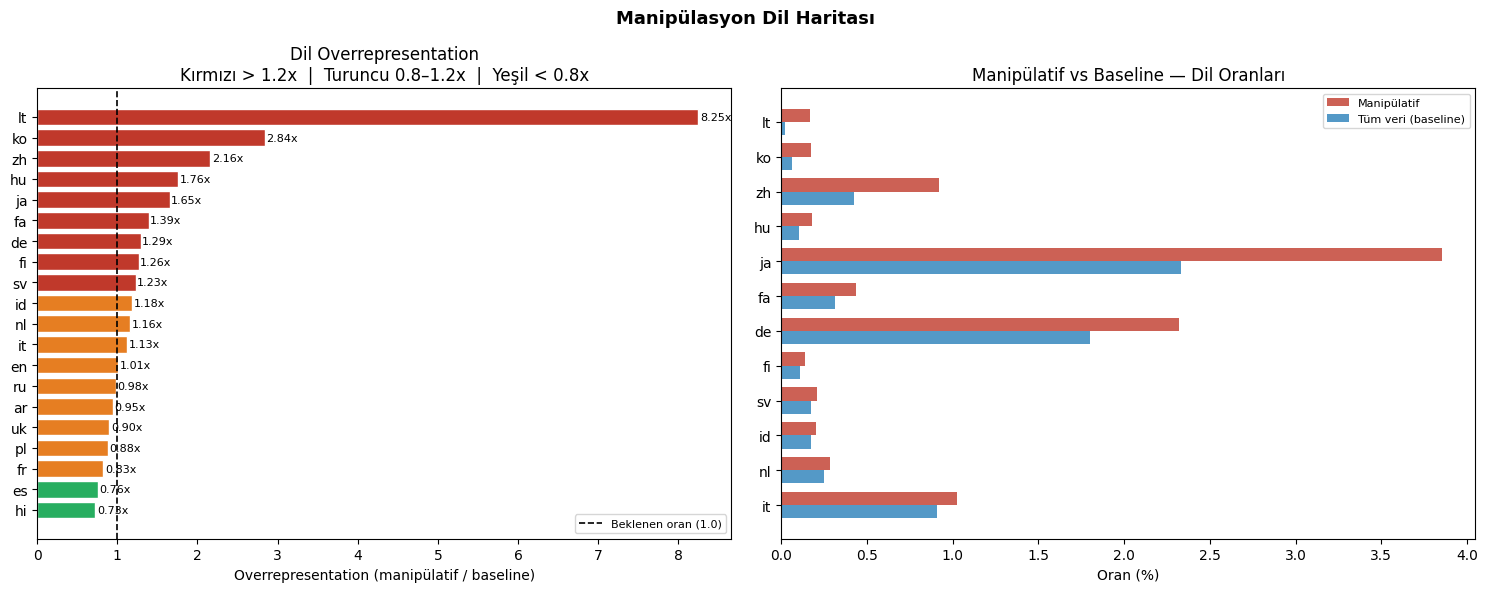


En yüksek overrepresentation:
          baseline  manipulation  overrepresentation
language                                            
lt        0.000204      0.001680               8.250
ko        0.000620      0.001758               2.838
zh        0.004262      0.009195               2.157
hu        0.001015      0.001785               1.759
ja        0.023343      0.038553               1.652
fa        0.003148      0.004372               1.389
de        0.017989      0.023195               1.289
fi        0.001077      0.001362               1.265
sv        0.001716      0.002105               1.227
id        0.001736      0.002053               1.183


In [19]:
TOP_LANG = 20

baseline_lang = post_clusters['language'].value_counts(normalize=True)
manip_lang    = (post_clusters[post_clusters['is_manipulation']]
                 ['language'].value_counts(normalize=True))

all_langs = baseline_lang.head(TOP_LANG).index.union(manip_lang.head(TOP_LANG).index)
lang_df = pd.DataFrame({
    'baseline':     baseline_lang.reindex(all_langs, fill_value=1e-9),
    'manipulation': manip_lang.reindex(all_langs, fill_value=0),
})
lang_df['overrepresentation'] = (lang_df['manipulation'] / lang_df['baseline']).round(3)
lang_df = lang_df.sort_values('overrepresentation', ascending=False).head(TOP_LANG)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sol: overrepresentation bar
colors_bar = ['#c0392b' if v > 1.2 else '#e67e22' if v > 0.8 else '#27ae60'
               for v in lang_df['overrepresentation']]
bars = axes[0].barh(lang_df.index[::-1], lang_df['overrepresentation'][::-1],
                    color=colors_bar[::-1], edgecolor='white')
axes[0].axvline(1.0, color='black', linewidth=1.2, linestyle='--', label='Beklenen oran (1.0)')
axes[0].set_xlabel('Overrepresentation (manipülatif / baseline)')
axes[0].set_title('Dil Overrepresentation\nKırmızı > 1.2x  |  Turuncu 0.8–1.2x  |  Yeşil < 0.8x')
for bar, val in zip(bars[::-1], lang_df['overrepresentation']):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}x', va='center', fontsize=8)
axes[0].legend(fontsize=8)

# Sağ: baseline vs manipulation oranı yan yana
x = np.arange(len(lang_df))
w = 0.38
top10 = lang_df.head(12)
axes[1].barh(np.arange(len(top10)) + w/2, top10['manipulation'][::-1]*100,
             w, color='#c0392b', alpha=0.8, label='Manipülatif')
axes[1].barh(np.arange(len(top10)) - w/2, top10['baseline'][::-1]*100,
             w, color='#2980b9', alpha=0.8, label='Tüm veri (baseline)')
axes[1].set_yticks(np.arange(len(top10)))
axes[1].set_yticklabels(top10.index[::-1])
axes[1].set_xlabel('Oran (%)')
axes[1].set_title('Manipülatif vs Baseline — Dil Oranları')
axes[1].legend(fontsize=8)

plt.suptitle('Manipülasyon Dil Haritası', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'fig4_language_map.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEn yüksek overrepresentation:')
print(lang_df[['baseline','manipulation','overrepresentation']].head(10).to_string())

## 5. Platform Haritası — Overrepresentation

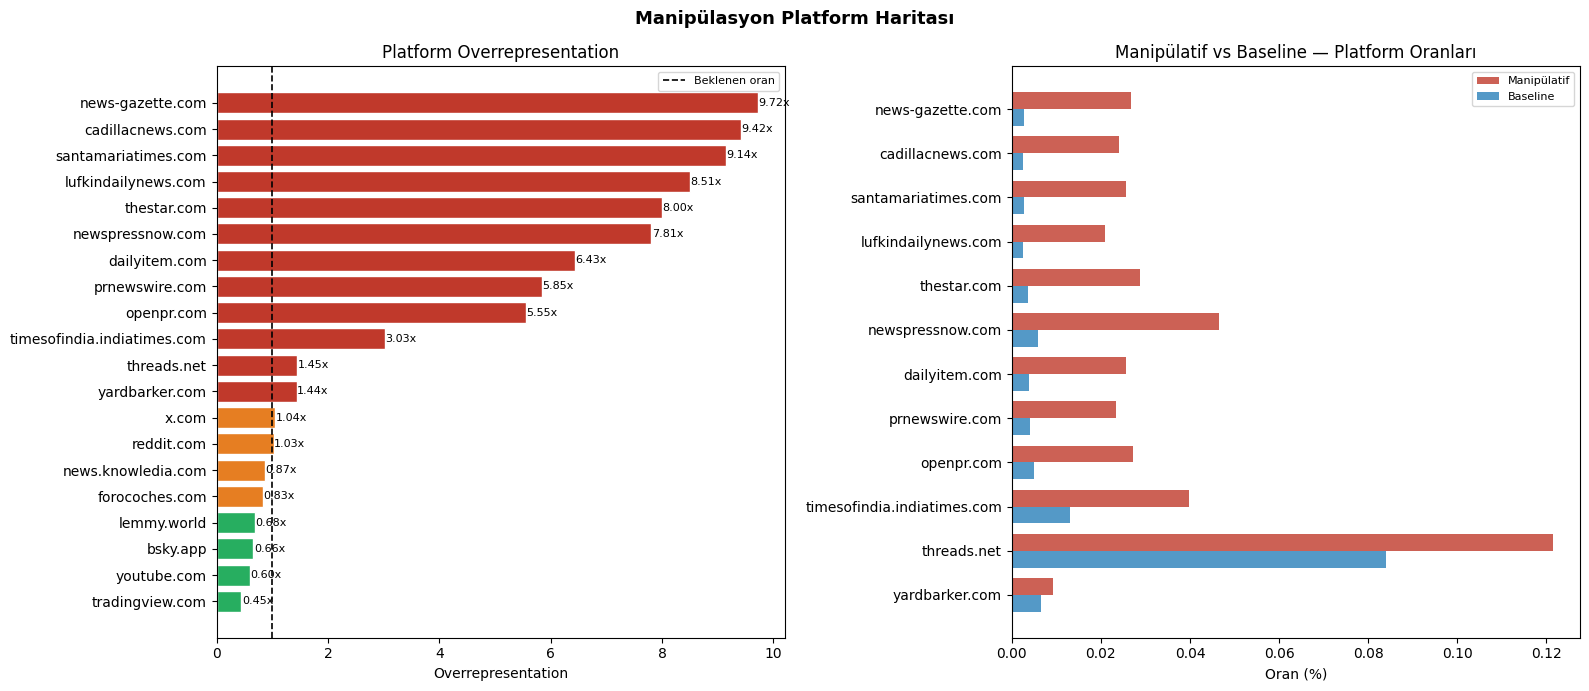


En yüksek overrepresentation:
                             baseline  manipulation  overrepresentation
domain                                                                 
news-gazette.com             0.000028      0.000268               9.721
cadillacnews.com             0.000026      0.000241               9.423
santamariatimes.com          0.000028      0.000256               9.143
lufkindailynews.com          0.000025      0.000209               8.505
thestar.com                  0.000036      0.000288               8.000
newspressnow.com             0.000060      0.000465               7.806
dailyitem.com                0.000040      0.000256               6.432
prnewswire.com               0.000040      0.000234               5.846
openpr.com                   0.000049      0.000273               5.554
timesofindia.indiatimes.com  0.000132      0.000398               3.026


In [20]:
TOP_DOM = 20

baseline_dom = post_clusters['domain'].value_counts(normalize=True)
manip_dom    = (post_clusters[post_clusters['is_manipulation']]
                ['domain'].value_counts(normalize=True))

all_doms = baseline_dom.head(TOP_DOM).index.union(manip_dom.head(TOP_DOM).index)
dom_df = pd.DataFrame({
    'baseline':     baseline_dom.reindex(all_doms, fill_value=1e-9),
    'manipulation': manip_dom.reindex(all_doms, fill_value=0),
})
dom_df['overrepresentation'] = (dom_df['manipulation'] / dom_df['baseline']).round(3)
dom_df = dom_df.sort_values('overrepresentation', ascending=False).head(TOP_DOM)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_bar = ['#c0392b' if v > 1.2 else '#e67e22' if v > 0.8 else '#27ae60'
               for v in dom_df['overrepresentation']]
bars = axes[0].barh(dom_df.index[::-1], dom_df['overrepresentation'][::-1],
                    color=colors_bar[::-1], edgecolor='white')
axes[0].axvline(1.0, color='black', linewidth=1.2, linestyle='--', label='Beklenen oran')
axes[0].set_xlabel('Overrepresentation')
axes[0].set_title('Platform Overrepresentation')
for bar, val in zip(bars[::-1], dom_df['overrepresentation']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}x', va='center', fontsize=8)
axes[0].legend(fontsize=8)

top12_dom = dom_df.head(12)
axes[1].barh(np.arange(len(top12_dom)) + 0.19, top12_dom['manipulation'][::-1]*100,
             0.38, color='#c0392b', alpha=0.8, label='Manipülatif')
axes[1].barh(np.arange(len(top12_dom)) - 0.19, top12_dom['baseline'][::-1]*100,
             0.38, color='#2980b9', alpha=0.8, label='Baseline')
axes[1].set_yticks(np.arange(len(top12_dom)))
axes[1].set_yticklabels(top12_dom.index[::-1])
axes[1].set_xlabel('Oran (%)')
axes[1].set_title('Manipülatif vs Baseline — Platform Oranları')
axes[1].legend(fontsize=8)

plt.suptitle('Manipülasyon Platform Haritası', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'fig5_platform_map.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEn yüksek overrepresentation:')
print(dom_df[['baseline','manipulation','overrepresentation']].head(10).to_string())

## 6. Dil × Platform — Ana Manipülasyon Haritası

İki görünüm:
- **Sol:** Mutlak manipülatif post sayısı (yoğunluk)
- **Sağ:** Overrepresentation oranı — baseline'a göre kaç kat fazla

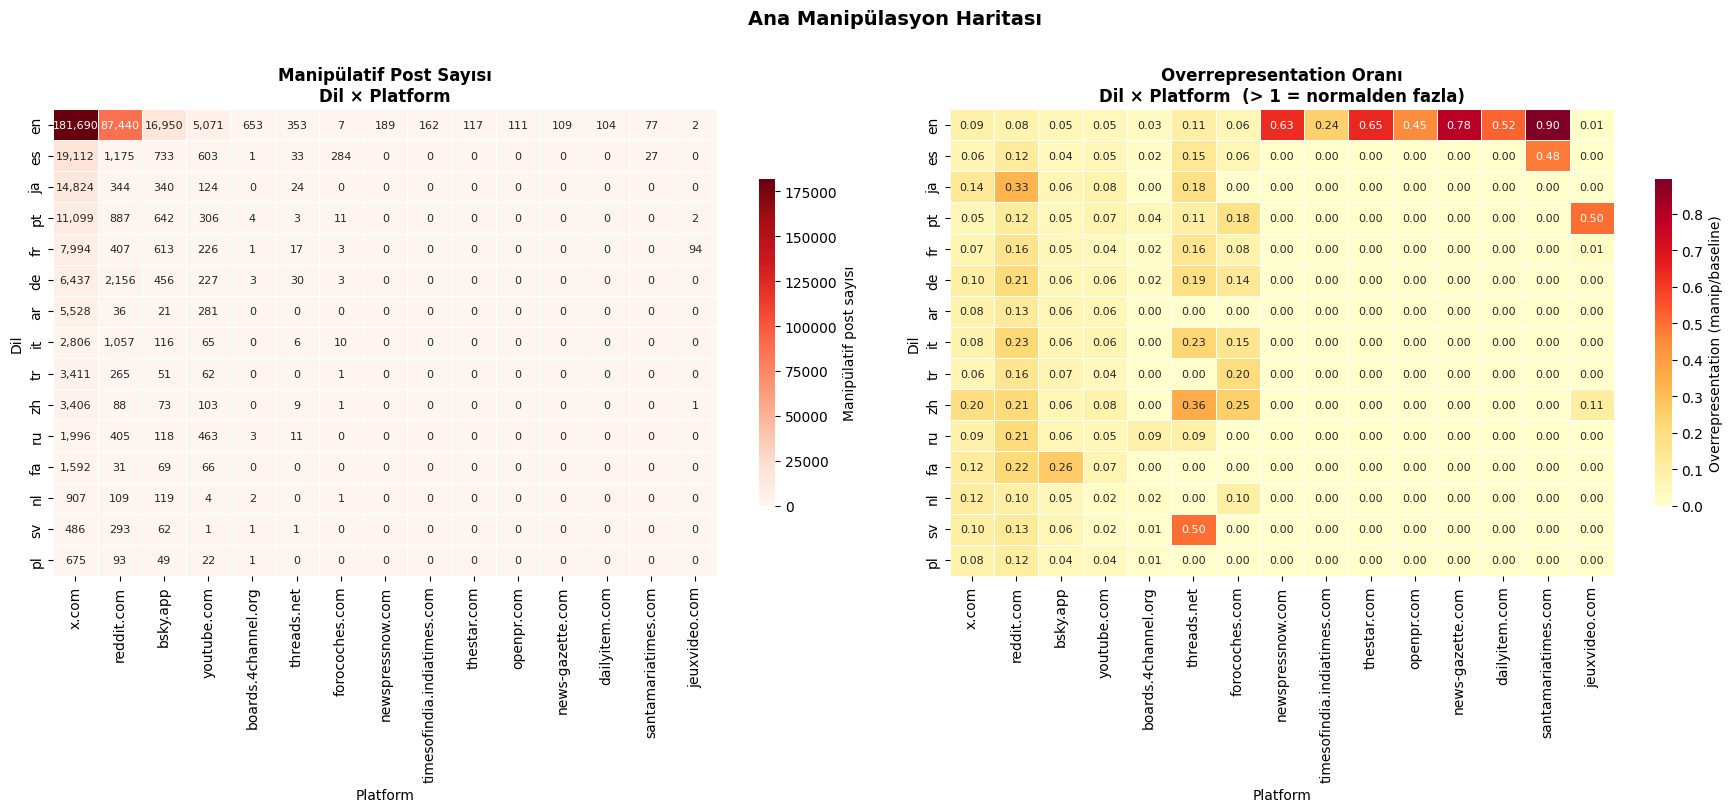

In [21]:
TOP_N = 15

manip_posts = post_clusters[post_clusters['is_manipulation']]
top_langs_m = manip_posts['language'].value_counts().head(TOP_N).index.tolist()
top_doms_m  = manip_posts['domain'].value_counts().head(TOP_N).index.tolist()

manip_pivot = (
    manip_posts[manip_posts['language'].isin(top_langs_m) & manip_posts['domain'].isin(top_doms_m)]
    .groupby(['language', 'domain']).size().unstack(fill_value=0)
    .reindex(index=top_langs_m, columns=top_doms_m, fill_value=0)
)

baseline_pivot = (
    post_clusters[post_clusters['language'].isin(top_langs_m) & post_clusters['domain'].isin(top_doms_m)]
    .groupby(['language', 'domain']).size().unstack(fill_value=0)
    .reindex(index=top_langs_m, columns=top_doms_m, fill_value=0)
)
overrep_pivot = (manip_pivot / (baseline_pivot + 1)).round(3)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(manip_pivot, ax=axes[0], cmap='Reds', annot=True, fmt=',d',
            linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'label': 'Manipülatif post sayısı', 'shrink': 0.7})
axes[0].set_title('Manipülatif Post Sayısı\nDil × Platform', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Dil')

sns.heatmap(overrep_pivot, ax=axes[1], cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'label': 'Overrepresentation (manip/baseline)', 'shrink': 0.7},
            vmin=0, vmax=overrep_pivot.values.max())
axes[1].set_title('Overrepresentation Oranı\nDil × Platform  (> 1 = normalden fazla)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Dil')

plt.suptitle('Ana Manipülasyon Haritası', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'fig6_manipulation_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
fig_html = px.imshow(
    manip_pivot,
    title='<b>Manipülasyon Haritası</b> — Dil × Platform Post Yoğunluğu',
    labels=dict(x='Platform', y='Dil', color='Manipülatif Post Sayısı'),
    color_continuous_scale='Reds', aspect='auto', text_auto=True, height=600, width=1000,
)
fig_html.update_layout(font=dict(size=11), title_font_size=15,
                       margin=dict(l=80, r=40, t=80, b=100))
fig_html.update_xaxes(tickangle=-30)
fig_html.show()

## 7. Kategori Sinyalleri — Radar Chart

In [23]:
radar_features = [f for f in [
    'mean_sentiment_extreme', 'mean_is_duplicate',
    'mean_cross_author_dup_count', 'mean_kw_fingerprint_shared',
    'mean_kw_density', 'mean_has_author'
] if f in cluster_summary.columns]

if radar_features:
    cs2 = cluster_summary.copy()
    cs2['category'] = cs2.apply(lambda r: get_category(r['cluster'], r['mean_organic_score']), axis=1)

    # Kategori bazlı ağırlıklı ortalama (post sayısına göre)
    cat_radar = (
        cs2[cs2['cluster'] >= 0]
        .groupby('category')
        .apply(lambda g: pd.Series({
            f: np.average(g[f], weights=g['post_count']) for f in radar_features
        }))
        .reindex(['Manipülasyon', 'Gri Bölge', 'Organik'])
    )
    # Normalize [0,1]
    for col in radar_features:
        mx = cat_radar[col].max()
        cat_radar[col] = cat_radar[col] / mx if mx > 0 else 0

    cats_labels = [f.replace('mean_', '').replace('_', ' ') for f in radar_features]

    fig = go.Figure()
    for cat, color in [('Manipülasyon','#c0392b'), ('Gri Bölge','#e67e22'), ('Organik','#27ae60')]:
        if cat not in cat_radar.index:
            continue
        vals = list(cat_radar.loc[cat, radar_features]) + [cat_radar.loc[cat, radar_features[0]]]
        fig.add_trace(go.Scatterpolar(
            r=vals, theta=cats_labels + [cats_labels[0]],
            fill='toself', name=cat, line_color=color, opacity=0.7,
        ))
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title='Kategori Bazlı Sinyal Radar (normalize, post ağırlıklı)',
        height=480, legend=dict(orientation='h', y=-0.1),
    )
    fig.show()
else:
    print('cluster_summary içinde radar feature bulunamadı.')